## 12 Random Forest
### Random Forest
By **Mohan Sirumalla**
***


### Data Preparation

In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format

In [11]:
# Read all sheets into a dictionary of DataFrames
all_sheets = pd.read_excel('12_glass.xlsx', sheet_name=None)
print(all_sheets.keys())

dict_keys(['Description', 'glass'])


In [12]:
df_desc=all_sheets['Description']
df=all_sheets['glass']
df_org=df.copy() #Backup


In [14]:
df_desc.head(20)

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [15]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### 1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

In [16]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [18]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [19]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [22]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

Duplicate records
No null values found in the DataFrame.


In [27]:
print(f"Unique values for Type: {df['Type'].unique()}")

Unique values for Type: [1 2 3 5 6 7]


### 2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

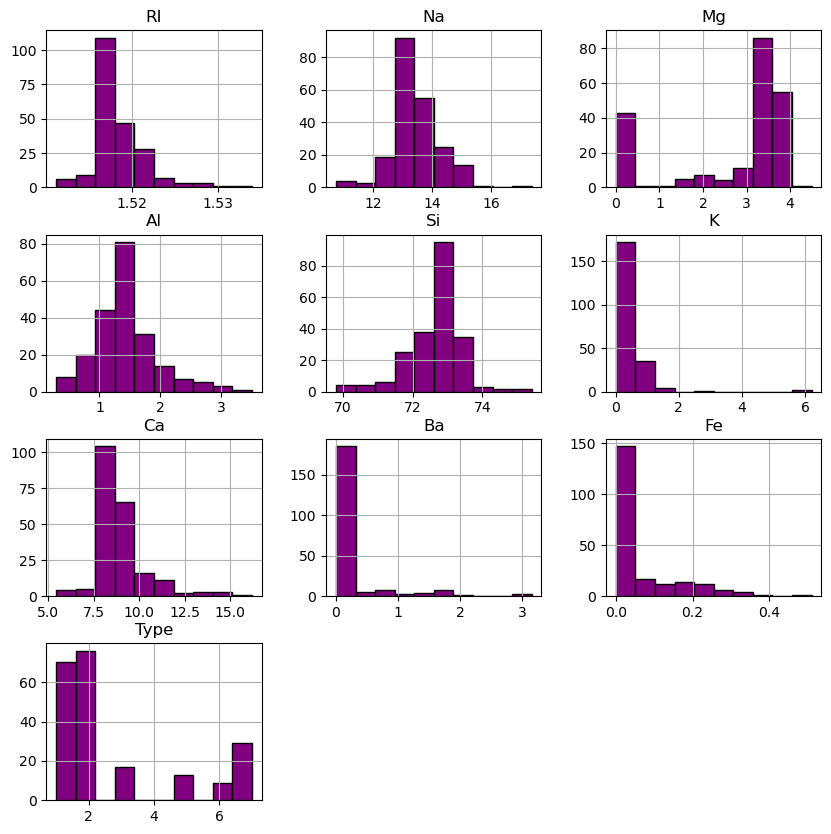

In [30]:
#histogram for each  feature
df.hist(bins=10,figsize=(10,10),color='purple', edgecolor='black')
plt.show()

In [ ]:
# Box Plot :- to analyse the distribution and see the outliers

In [32]:
# Select  numeric columns and non numeric columns
numeric_cols_df = df.select_dtypes(include='number')
print('Numberic',numeric_cols_df.columns)
non_numeric_cols_df = df.select_dtypes(exclude='number')
print('Non-Numberic',non_numeric_cols_df.columns)

Numberic Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')
Non-Numberic Index([], dtype='object')


In [33]:
numeric_cols_df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

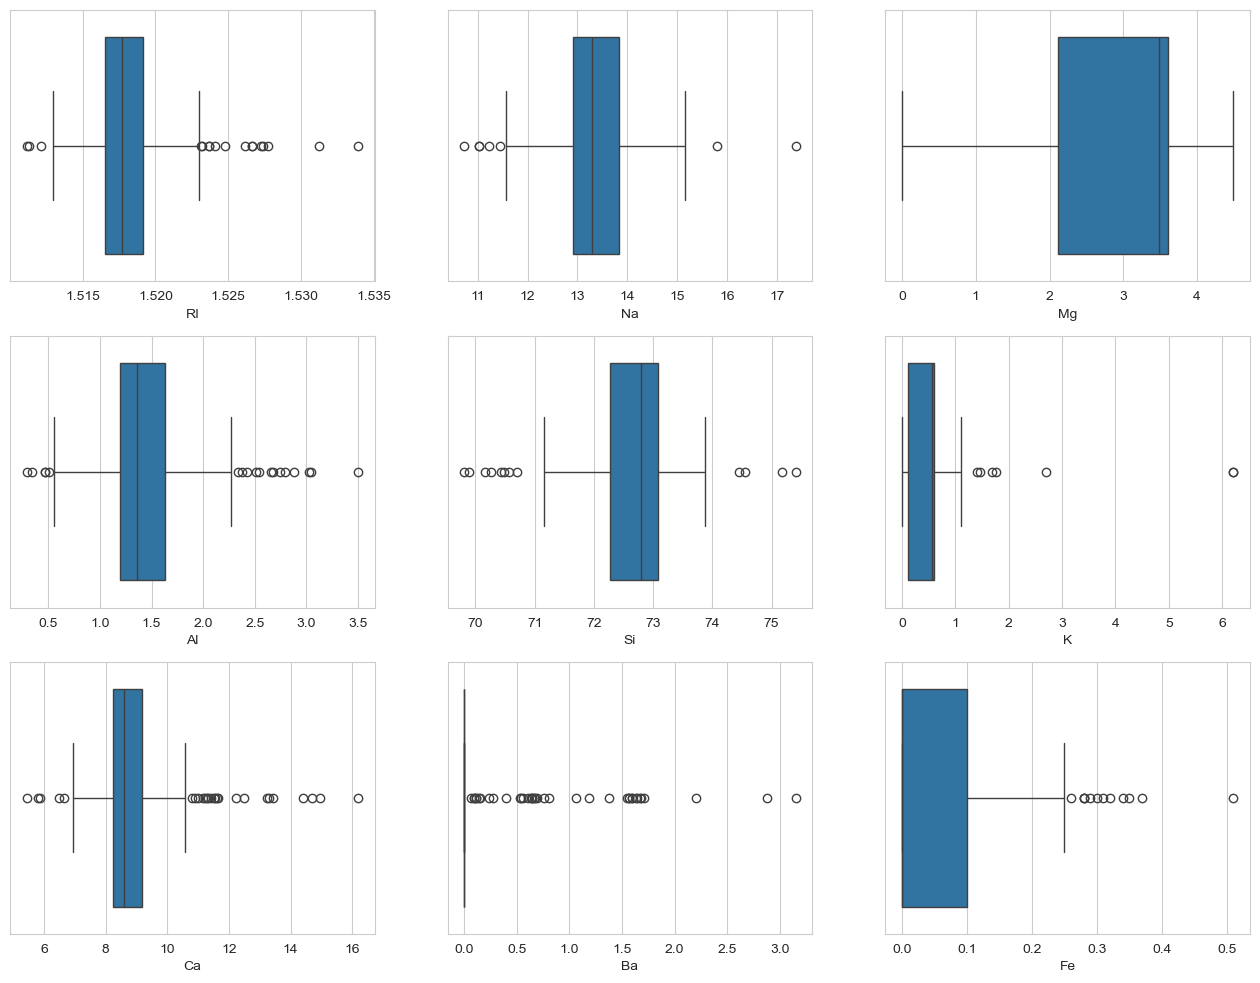

In [36]:
# Define the columns you want to plot
columns_to_plot = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(x='RI',data=df)
plt.subplot(3,3,2)
sns.boxplot(x='Na',data=df)
plt.subplot(3,3,3)
sns.boxplot(x='Mg',data=df)
plt.subplot(3,3,4)
sns.boxplot(x='Al',data=df)
plt.subplot(3,3,5)
sns.boxplot(x='Si',data=df)
plt.subplot(3,3,6)
sns.boxplot(x='K',data=df)
plt.subplot(3,3,7)
sns.boxplot(x='Ca',data=df)
plt.subplot(3,3,8)
sns.boxplot(x='Ba',data=df)
plt.subplot(3,3,9)
sns.boxplot(x='Fe',data=df)
plt.show()

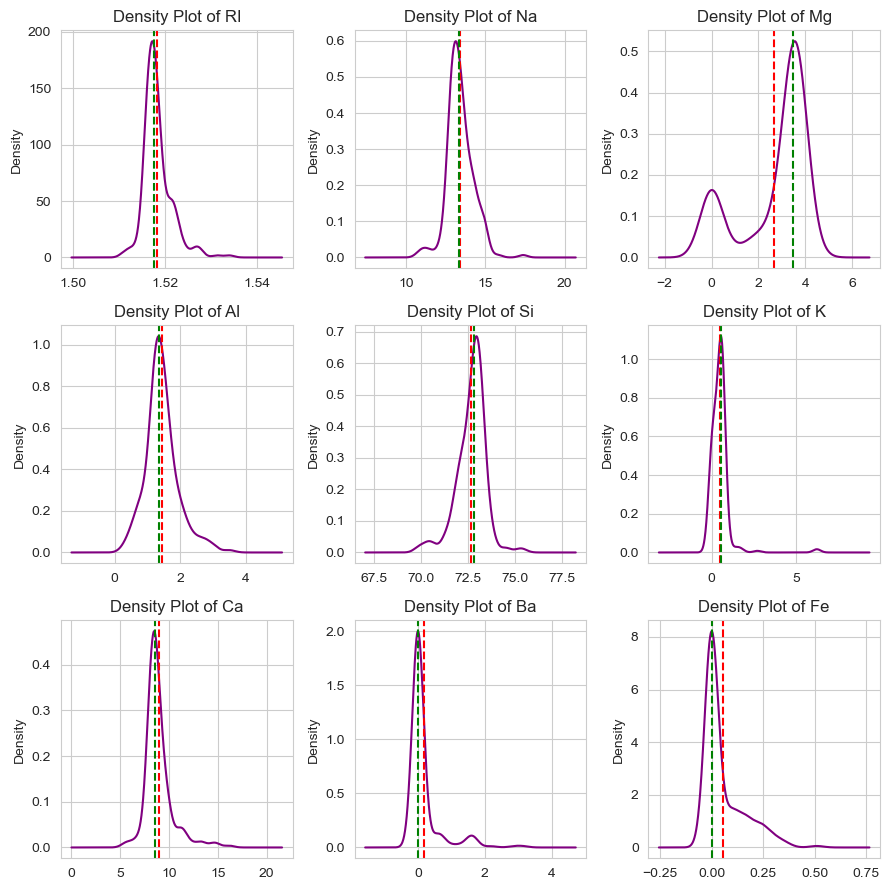

In [43]:
#Density Plots

# Create a figure and axis array with subplots
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()
numeric_cols_df.drop('Type',axis=1,inplace=True)
# Loop through each numeric column and plot its histogram
for i, column in enumerate(numeric_cols_df.columns):
    ax = numeric_cols_df[column].plot.density(ax = axes[i], color='purple')
    ax.axvline(numeric_cols_df[column].mean(), color = 'red', linestyle ='--')
    ax.axvline(numeric_cols_df[column].median(), color = 'green', linestyle ='--')
    ax.set_title(f'Density Plot of {column}')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [44]:
# Calculate skewness for each numeric column
skewness_values = numeric_cols_df.skew()

# Print the skewness values
skewness_values

RI    1.625431
Na    0.454181
Mg   -1.152559
Al    0.907290
Si   -0.730447
K     6.551648
Ca    2.047054
Ba    3.416425
Fe    1.754327
dtype: float64

**Distribution of Features**
   * RI: Appears normally distributed with a slight right skew.
   * Na: Slight right skew with a central peak around 13-14.
   * Mg: Bimodal distribution, indicating two distinct glass types with different Mg content.
   * Al: Right-skewed, with most values between 1 and 1.5.
   * Si: Nearly normal distribution, centered around 72-73.
   * K: Highly right-skewed, with most values concentrated at 0 but a long tail up to 6.
   * Ca: Right-skewed with most values clustered around 8-9.5, but with some higher values extending to 16.
   * Ba: Mostly zero for many samples, with a few having significant Ba content.
   * Fe: Mostly near zero, with some slight right-skewed distribution.


In [62]:
#Outlier Detection for all columsn
for column in numeric_cols_df.columns:
  print('Outliers calculation for', column)

  #Quartile 1
  Q1=numeric_cols_df[column].quantile(0.25)

  #Quartile 3
  Q3=numeric_cols_df[column].quantile(0.75)

  #IQR
  IQR=Q3-Q1

  #Upper-Limit
  UL = Q3+(1.5*IQR)

  #Lower-Limit
  LL = Q1-(1.5*IQR)

  #Outliers
  Outliers = numeric_cols_df[(numeric_cols_df[column] >UL) | (numeric_cols_df[column]< LL)]
  print(Outliers.head())
  print('Number of outlier entries', Outliers.shape[0])
  print('Percentage of outlier entries', Outliers.shape[0]/numeric_cols_df.shape[0])
  print('_______________________________________________________________________________')

Outliers calculation for RI
          RI     Na    Mg    Al     Si     K     Ca   Ba    Fe
47   1.52667  13.99  3.70  0.71  71.57  0.02   9.82  0.0  0.10
50   1.52320  13.72  3.72  0.51  71.75  0.09  10.06  0.0  0.16
56   1.51215  12.99  3.47  1.12  72.98  0.62   8.35  0.0  0.31
103  1.52725  13.80  3.15  0.66  70.57  0.08  11.64  0.0  0.00
104  1.52410  13.83  2.90  1.17  71.15  0.08  10.79  0.0  0.00
Number of outlier entries 17
Percentage of outlier entries 0.0794392523364486
_______________________________________________________________________________
Outliers calculation for Na
          RI     Na    Mg    Al     Si     K     Ca    Ba    Fe
105  1.52475  11.45  0.00  1.88  72.19  0.81  13.24  0.00  0.34
106  1.53125  10.73  0.00  2.10  69.81  0.58  13.30  3.15  0.28
110  1.52664  11.23  0.00  0.77  73.21  0.00  14.68  0.00  0.00
111  1.52739  11.02  0.00  0.75  73.08  0.00  14.96  0.00  0.00
166  1.52151  11.03  1.71  1.56  73.44  0.58  11.62  0.00  0.00
Number of outlier entrie

Since our outlier percentage ranges from only 0.03% to 0.17%, these extreme values represent a very small fraction of the dataset. Given this, their impact on the Random Forest model is likely minimal, as tree-based algorithms are inherently robust to outliers

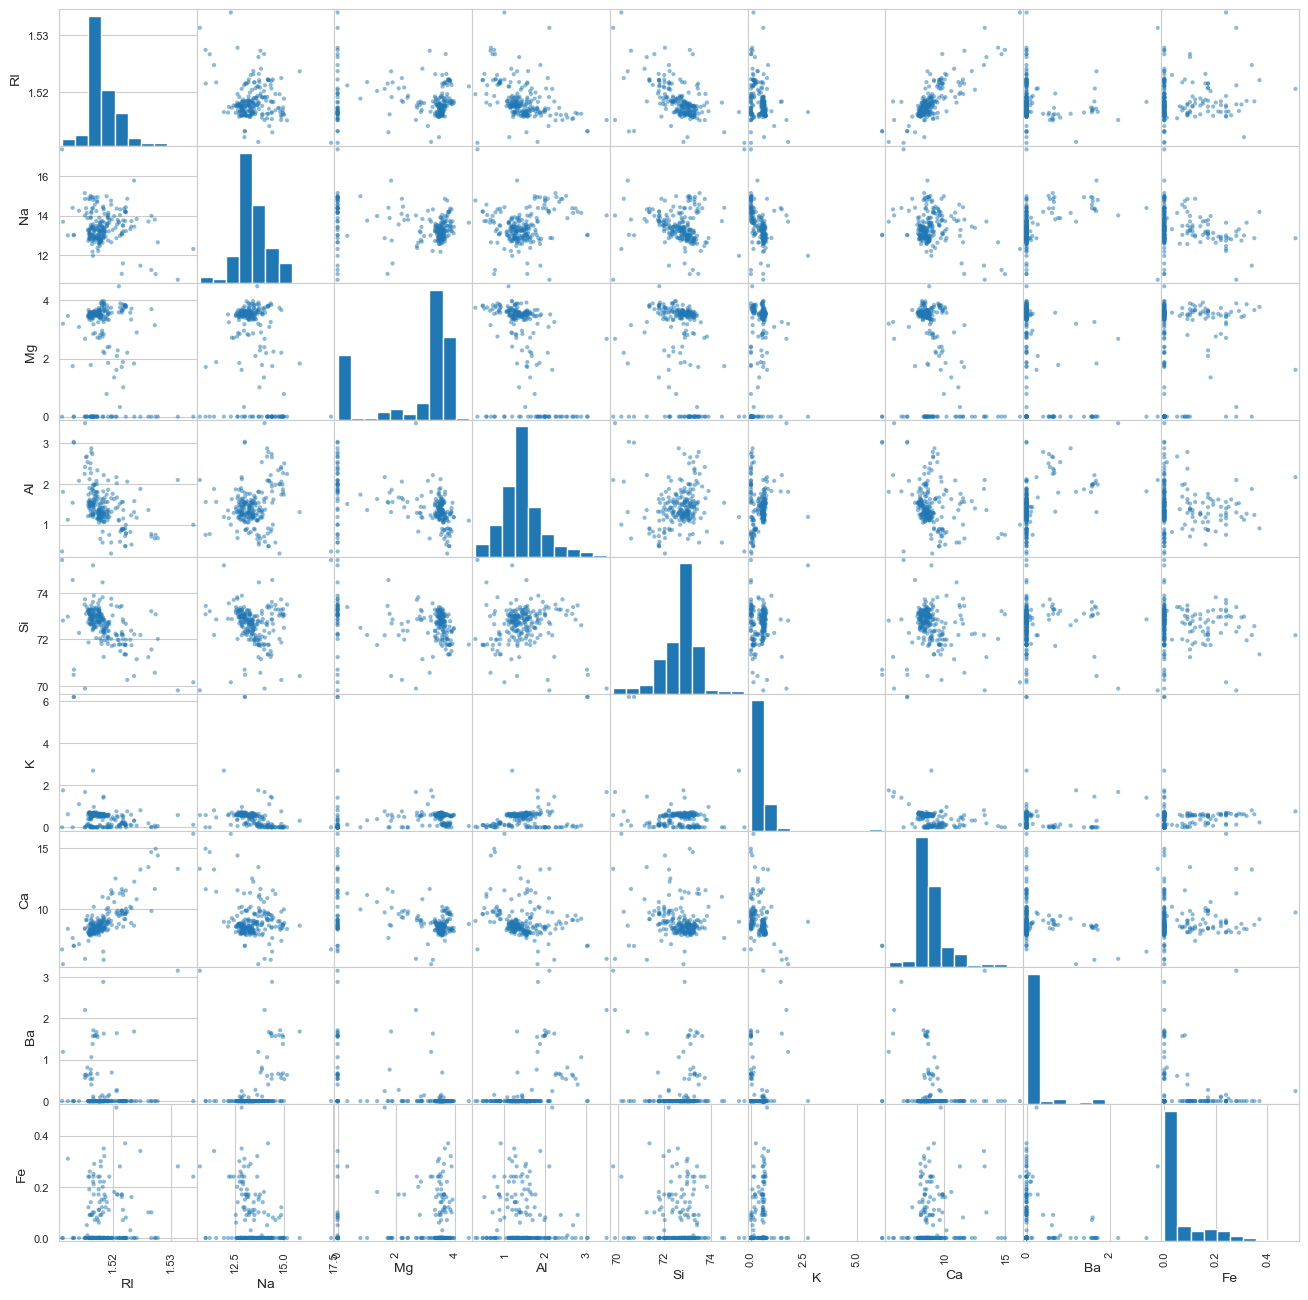

In [63]:
from pandas.plotting import scatter_matrix
scatter_matrix(numeric_cols_df,figsize=(16,16));

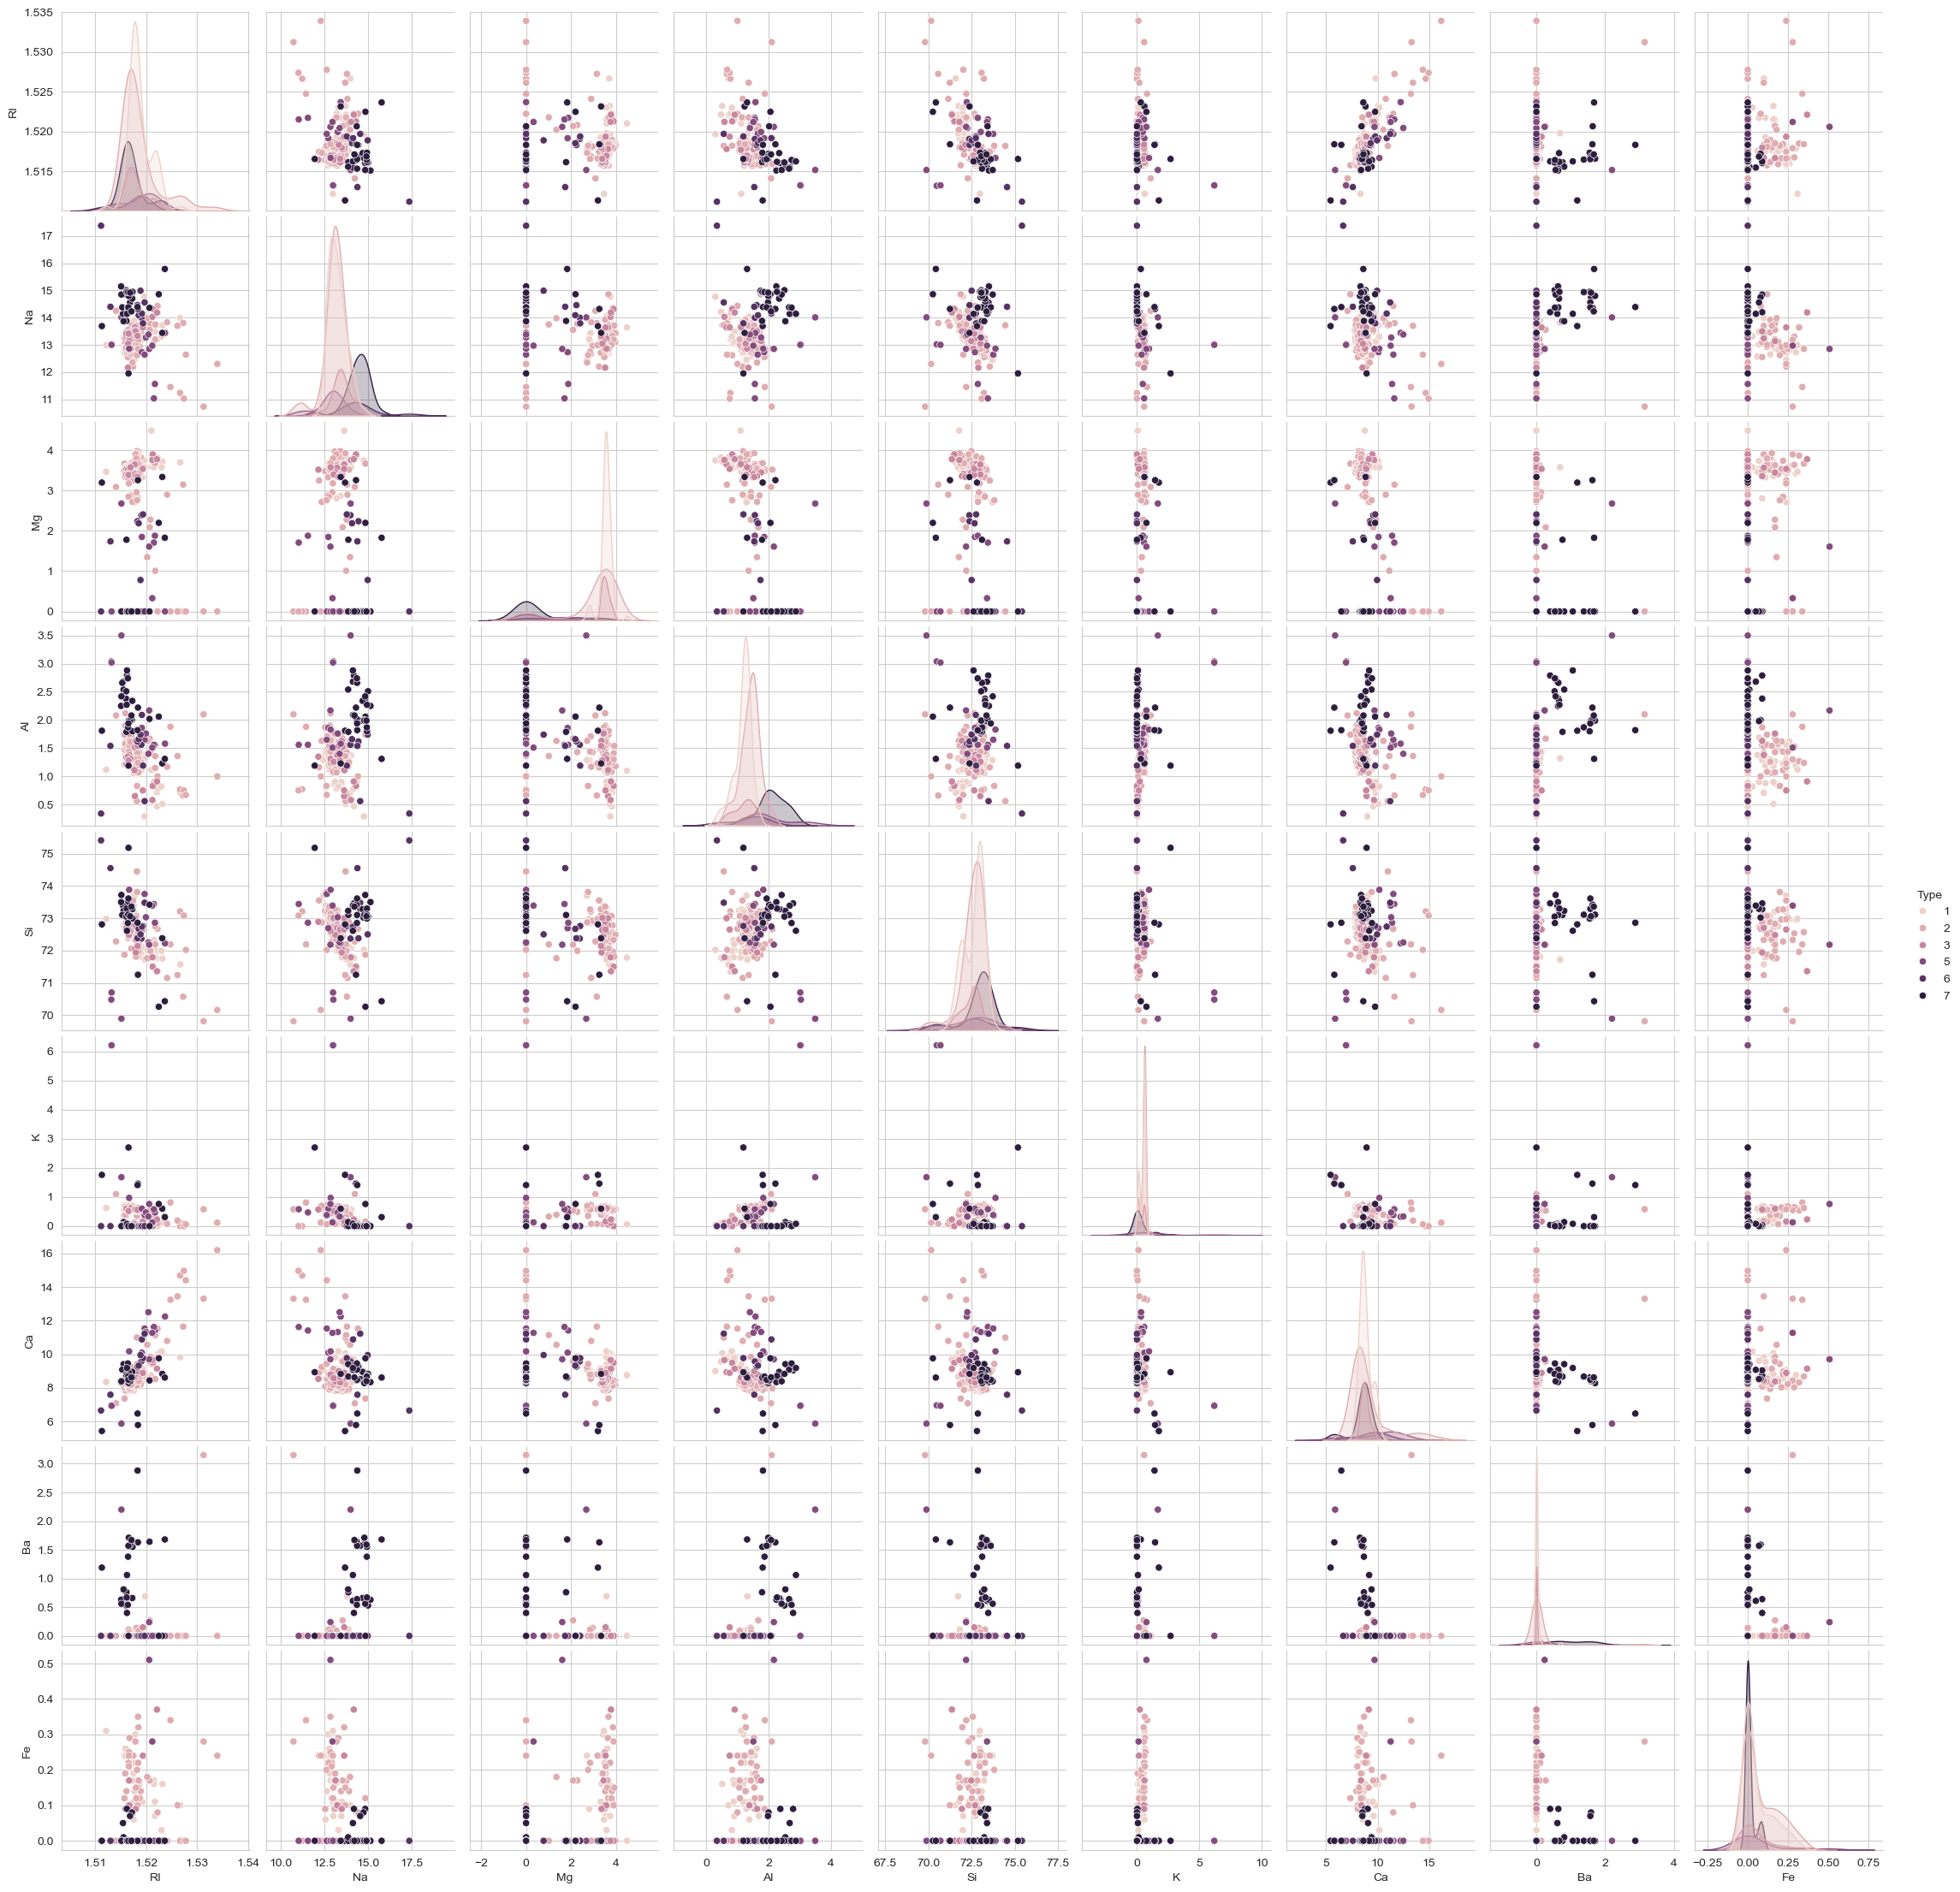

In [64]:
# Visualizing the relationships with a pairplot, colored by Outcome
sns.pairplot(df, hue='Type', vars= ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'])
plt.show()

<Axes: >

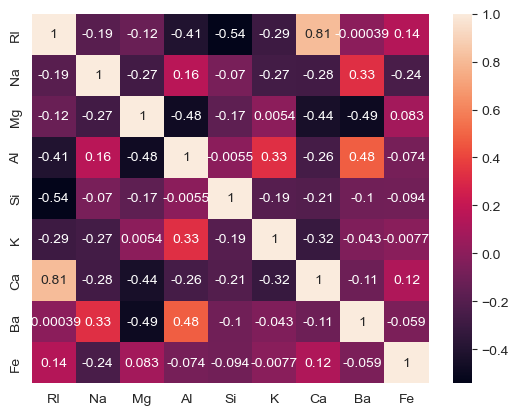

In [65]:
corrmat=numeric_cols_df.corr()
sns.heatmap(corrmat, annot=True)

In [66]:
## Categorical Variables Analysis Having 1tp 7 categories
type_percentages = df['Type'].value_counts(normalize=True) * 100
# Print the results
type_percentages


Type
2    35.514019
1    32.710280
7    13.551402
3     7.943925
5     6.074766
6     4.205607
Name: proportion, dtype: float64

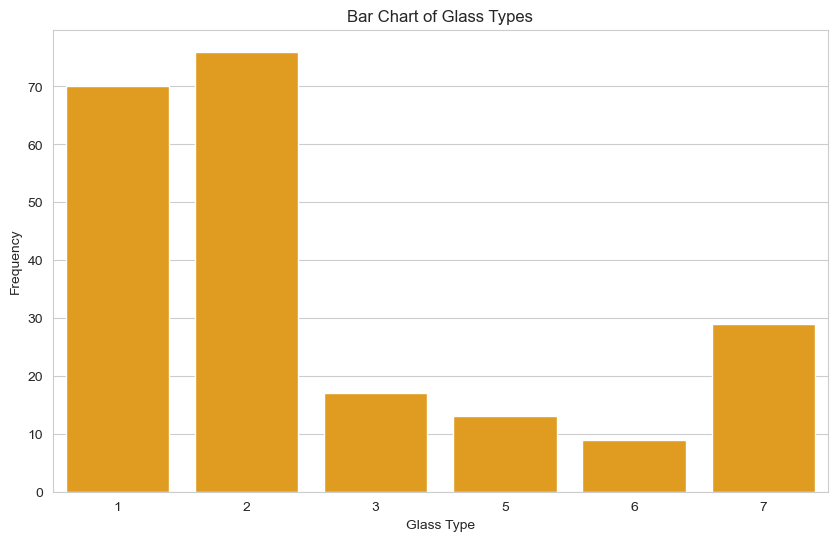

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'dataset' is your DataFrame and 'Type' is the column you want to plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Type', data=df, color = 'orange')
plt.title('Bar Chart of Glass Types')
plt.xlabel('Glass Type')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['Type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.cubehelix_palette(), startangle=90)
plt.title(f'Pie Chart of {col}')
plt.ylabel('')  # Remove the y-label in case of pie chart
plt.show()

**Observations:**
   * About 33% of our data entries are float processed building windows and 36% are non float.
   * 14% of our data are head lamps, whereas 8% are vehicle windows (float processed)
   * The remaining 10% of our data constitute containers and tableware.


### 3: Data Preprocessing

#### 1. Check for missing values in the dataset and decide on a strategy for handling them. Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.

**Handling Outliers**

Since our dataset is small and outliers make up only 0.1% of the data, explicitly handling them could distort the model.\
Instead, we will rely on other methods to normalize the data and achieve a more Gaussian-like distribution, ensuring better model performance without unnecessary data loss.


#### 2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.

In [71]:
# data partition
df_new = df.copy()
target_name='Type'
y= df_new[target_name]#given predictions - training data 
X=df_new.drop(target_name,axis=1)#dropping the Type column and keeping 

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])


#### 3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

In [74]:
from sklearn.preprocessing import StandardScaler
# 2. Select the columns to scale
columns_to_scale = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

# 3. Instantiate the StandardScaler
scaler = StandardScaler()

# 4. Fit and transform the selected columns and assign the result back to the DataFrame
# The result of fit_transform is a NumPy array, which is then assigned back to the specific columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

## Handling imbalance Data
During our exploratory data analysis (EDA), we observed that our dataset has an imbalanced class distribution (some classes have <10% representation), meaning some glass types have significantly fewer samples than others. This imbalance can lead to biased predictions, where the model favors majority classes and underperforms on minority classes.

To address this issue, we apply Synthetic Minority Over-sampling Technique (SMOTE). SMOTE generates synthetic examples for the minority class by interpolating between existing samples. This enhances class representation without simply duplicating data, leading to better generalization in classification models.

In [75]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451,1
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451,1
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451,1
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451,1
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451,1
...,...,...,...,...,...,...,...,...,...,...
209,-0.704815,0.898681,-1.865511,2.881125,-0.052974,-0.640968,0.157088,1.783978,-0.586451,7
210,-0.500178,1.856097,-1.865511,1.094342,0.529374,-0.763919,-0.392276,2.852405,-0.586451,7
211,0.754046,1.168721,-1.865511,1.154570,0.995252,-0.763919,-0.364103,2.953200,-0.586451,7
212,-0.612399,1.193270,-1.865511,0.993960,1.241133,-0.763919,-0.335931,2.812087,-0.586451,7


### 4: Random Forest Model Implementation

#### 1. Divide the data into train and test split.

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [77]:
print("\nTraining set class distribution before balancing:")
print(pd.Series(y_train).value_counts())


Training set class distribution before balancing:
1    62
0    59
5    21
2    14
3     9
4     6
Name: count, dtype: int64


In [79]:
from imblearn.over_sampling import SMOTE
#  Apply SMOTE to the training data to balance classes
# SMOTE synthesizes new examples from the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nTraining set class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Training set class distribution after SMOTE:
1    62
2    62
0    62
5    62
3    62
4    62
Name: count, dtype: int64


#### 2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.

In [82]:
from sklearn.ensemble import RandomForestClassifier
#  Train a model on the balanced data
model = RandomForestClassifier(random_state=42)



#### 3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

In [83]:
# Train a model on the balanced data

model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [85]:
from sklearn.metrics import classification_report
# 5. Evaluate the model on the original, untouched test data
y_pred = model.predict(X_test)
print("\nEvaluation on test set:")
# Use classification report for better evaluation of imbalanced data
print(classification_report(y_test, y_pred))


Evaluation on test set:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.92      0.79      0.85        14
           2       0.40      0.67      0.50         3
           3       1.00      0.75      0.86         4
           4       1.00      1.00      1.00         3
           5       0.89      1.00      0.94         8

    accuracy                           0.84        43
   macro avg       0.84      0.84      0.83        43
weighted avg       0.86      0.84      0.84        43



### 5: Bagging and Boosting Methods

#### Apply the Bagging and Boosting methods and compare the results.

In [92]:
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedBaggingClassifier

# --- Bagging Classifier (using resampled data) ---
bagging_model = BaggingClassifier(random_state=42)
bagging_model.fit(X_train_resampled, y_train_resampled)
y_pred_bag = bagging_model.predict(X_test)
print("\n--- Bagging Classifier Results (with Undersampling) ---")
# Get the full classification report including precision, recall, and f1-score
print(classification_report(y_test, y_pred_bag))

# --- Boosting Classifier (using resampled data) ---
# Boosting works sequentially, so it can sometimes struggle with extremely undersampled datasets.
# We apply it to the resampled data for direct comparison.
boosting_model = GradientBoostingClassifier(random_state=42)
boosting_model.fit(X_train_resampled, y_train_resampled)
y_pred_boost = boosting_model.predict(X_test)
print("\n--- Gradient Boosting Classifier Results (with Undersampling) ---")
print(classification_report(y_test, y_pred_boost))


--- Bagging Classifier Results (with Undersampling) ---
              precision    recall  f1-score   support

           0       0.62      0.73      0.67        11
           1       0.80      0.57      0.67        14
           2       0.40      0.67      0.50         3
           3       0.75      0.75      0.75         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         8

    accuracy                           0.74        43
   macro avg       0.76      0.79      0.76        43
weighted avg       0.77      0.74      0.75        43


--- Gradient Boosting Classifier Results (with Undersampling) ---
              precision    recall  f1-score   support

           0       0.75      0.82      0.78        11
           1       0.86      0.86      0.86        14
           2       1.00      0.67      0.80         3
           3       1.00      0.75      0.86         4
           4       0.75      1.00      0.86         3
        

### Additional Notes:

#### 1. Explain Bagging and Boosting methods. How is it different from each other.

**Bagging and Boosting** are both ensemble learning techniques used to improve model performance by combining multiple models. The main difference is that:
   * Bagging reduces variance by training models independently.
   * Boosting reduces bias by training models sequentially, focusing on previous errors.

Bagging (Bootstrap Aggregating) aims to reduce model variance by training multiple models on different random subsets of the dataset. These subsets are created using bootstrapping, where data points are sampled with replacement. 

Boosting focuses on improving model accuracy by training models sequentially. Each new model pays more attention to the data points that were misclassified by previous models. Over time, the ensemble becomes better at handling difficult cases.

|Feature|Bagging|Boosting|
|----|-----|----|
|Training style|	Trains independent models	|Trains sequential models|
|Main goal	|Reduce variance	|Reduce bias|
|Handling errors	|All samples treated equally	|Focuses on misclassified samples|
|Overfitting	|It is less sesitive to overfitting	|More prone to overfitting|
|Parallel training	|Yes |it supports parallel computing	|No it does not supports parallel computing|
|Sensitivity to noise	|It is not affected by noise and outliers	|Sensitive to noise and outliers|

#### 2. Explain how to handle imbalance in the data.

**Resampling,** which modifies the sample distribution, is a frequently used technique for handling very unbalanced datasets. This can be accomplished by either over-sampling, which adds more examples from the minority class, or under-sampling, which removes samples from the majority class. One method for reducing the difficulties caused by severely skewed datasets is resampling, which balances the class distribution.

**Balancing data with the Imbalanced-Learn module in Python**

In the world of fixing imbalanced data, there are some smart tricks. Scientists have come up with advanced methods to handle this issue.

For example, one clever way involves grouping together the majority class data and then carefully removing some of it. This helps keep the important details while making things more balanced. Another cool technique for adding more data to the minority class is not just making exact copies but tweaking them a bit to create a more diverse set.

**Synthetic Minority Oversampling Technique (SMOTE)**

SMOTE is used to generate artificial/synthetic samples for the minority class. This technique works by randomly choosing a sample from a minority class and determining K-Nearest Neighbors for this sample, then the artificial sample is added between the picked sample and its neighbors.

**NearMiss** is an under-sampling technique that aims to equalize the class distribution by considering the distances between instances, ensuring that the majority class becomes comparable to the minority class.